# M15 v6: Fixed Cross-Task Consistency Scorer (M2 Backbone + Correct Prototypes)

This notebook follows the Model_Training_Protocol.md requirements for Open-World evaluation. It loads the pre-trained M2 sound backbone and calibrates a Prototypical Disease Head (M13 architecture) to properly compute cross-task structural disagreement.

In [1]:
# ============================================================
# Section 1: Environment Setup & Dependencies
# ============================================================
import os, sys, math, time, glob, random, json, shutil
from collections import defaultdict
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from IPython.display import display, FileLink

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Device: {DEVICE} ({GPU_NAME})')


Device: cuda (Tesla T4)


In [6]:
# ============================================================
# Section 2: Configuration & Hyperparameters
# ============================================================
CFG = {
    'sample_rate': 16000, 'duration_s': 8.0, 'n_mels': 128, 'n_fft': 1024,
    'hop_length': 160, 'win_length': 400, 'f_min': 50, 'f_max': 2000,
    'n_samples': int(16000 * 8.0), 'n_frames': 1 + math.floor(128000 / 160),
    'batch_size': 32,
    'm2_ckpt': '/kaggle/input/datasets/barshonbasak/m2-checkpoint/best_model.pth',
    'm13_ckpt': '/kaggle/input/datasets/adharabasak/m13-checkpoint/best_model.pth',
    'ckpt_dir': '/kaggle/working/checkpoints',
    'results_dir': '/kaggle/working/results',
}
os.makedirs(CFG['ckpt_dir'], exist_ok=True)
os.makedirs(CFG['results_dir'], exist_ok=True)

def get_data_root():
    paths = ["/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files",
             "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/",
             "./data/audio_and_txt_files"]
    for p in paths:
        if os.path.exists(p): return p
    if os.path.exists("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            if any(f.endswith(".wav") for f in files) and any(f.endswith(".txt") for f in files):
                return root
    return None

def find_ckpt(name_hint):
    if os.path.exists(f"/content/drive/MyDrive/OWMTL/{name_hint}/checkpoints/best_model.pth"):
        return f"/content/drive/MyDrive/OWMTL/{name_hint}/checkpoints/best_model.pth"
    if os.path.exists(f"/content/drive/MyDrive/OWMTL/{name_hint}/best_model.pth"):
        return f"/content/drive/MyDrive/OWMTL/{name_hint}/best_model.pth"
    if os.path.exists("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            if "best_model.pth" in files and name_hint.lower() in root.lower():
                return os.path.join(root, "best_model.pth")
        for root, dirs, files in os.walk("/kaggle/input"):
            if "best_model.pth" in files: # fallback: any best_model
                return os.path.join(root, "best_model.pth")
    return None

CFG['data_root'] = get_data_root()
CFG['m2_ckpt'] = find_ckpt("m2") or '/content/drive/MyDrive/OWMTL/M2/checkpoints/best_model.pth'
CFG['m13_ckpt'] = find_ckpt("m13") or '/content/drive/MyDrive/OWMTL/M13/checkpoints/best_model.pth'

print(f"Data root: {CFG['data_root']}")


Data root: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files


In [8]:
# ============================================================
# Pre-Flight Check: Verify Attachments & Checkpoints
# ============================================================
print("--- PRE-FLIGHT CHECK ---")
if CFG['data_root']:
    print(f"✅ Dataset found at: {CFG['data_root']}")
else:
    print(f"❌ Dataset NOT FOUND! Please attach the ICBHI dataset.")

if os.path.exists(CFG['m2_ckpt']):
    print(f"✅ M2 Checkpoint found: {CFG['m2_ckpt']}")
else:
    print(f"❌ M2 Checkpoint NOT FOUND! Ensure M2 output is attached to Kaggle or Colab drive is mounted.")

if os.path.exists(CFG['m13_ckpt']):
    print(f"✅ M13 Checkpoint found: {CFG['m13_ckpt']}")
else:
    print(f"❌ M13 Checkpoint NOT FOUND! Ensure M13 output is attached to Kaggle or Colab drive is mounted.")
print("------------------------")


--- PRE-FLIGHT CHECK ---
✅ Dataset found at: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
✅ M2 Checkpoint found: /kaggle/input/datasets/barshonbasak/m2-checkpoint/best_model.pth
✅ M13 Checkpoint found: /kaggle/input/datasets/adharabasak/m13-checkpoint/best_model.pth
------------------------


In [9]:
# ============================================================
# Section 3: Dataset Loading & Patient-Independent Splitting
# ============================================================
import librosa
import re
ICBHI_KNOWN_DISEASES = {'COPD': 0, 'Healthy': 1, 'URTI': 2}
ICBHI_UNKNOWN_DISEASES = {'Pneumonia': -1, 'Bronchiectasis': -1, 'Bronchiolitis': -1, 'Asthma': -1, 'LRTI': -1}

def extract_log_mel(wav_path, start, end, cfg):
    try:
        audio, _ = librosa.load(wav_path, sr=cfg['sample_rate'], offset=start, duration=max(end-start, 0.05), mono=True)
        if len(audio) == 0: raise ValueError
    except:
        return np.zeros((1, cfg['n_mels'], cfg['n_frames']), dtype=np.float32)
    n_s = cfg['n_samples']
    if len(audio) < n_s: audio = np.tile(audio, math.ceil(n_s/len(audio)))[:n_s]
    else: audio = audio[:n_s]
    mel = librosa.feature.melspectrogram(y=audio, sr=cfg['sample_rate'], n_mels=cfg['n_mels'], n_fft=cfg['n_fft'], hop_length=cfg['hop_length'], win_length=cfg['win_length'], fmin=cfg['f_min'], fmax=cfg['f_max'], power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    if log_mel.shape[1] < cfg['n_frames']: log_mel = np.pad(log_mel, ((0,0),(0,cfg['n_frames']-log_mel.shape[1])))
    return log_mel[:, :cfg['n_frames']][np.newaxis, :, :].astype(np.float32)

def load_diagnosis_map(data_root):
    target_names = ["patient_diagnosis.csv", "ICBHI_Challenge_diagnosis.txt", "patient_diagnosis.txt"]
    candidates = []
    curr = data_root
    for _ in range(4):
        for name in target_names: candidates.append(os.path.join(curr, name))
        parent = os.path.dirname(curr)
        if parent == curr: break
        curr = parent
    if os.path.exists("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            for name in target_names:
                if name in files: candidates.append(os.path.join(root, name))

    for path in candidates:
        if not os.path.exists(path): continue
        diag_map = {}
        with open(path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                line_str = line.strip()
                if not line_str: continue
                parts = [p.strip() for p in re.split(r'[,;\t\s]+', line_str) if p.strip()]
                if len(parts) >= 2:
                    try: diag_map[int(parts[0])] = parts[1]
                    except ValueError: continue
        if diag_map: return diag_map
    
    print("Warning: Using hardcoded diagnosis fallback.")
    def get_dis(pid):
        h = {101, 102, 121, 122, 123, 125, 126, 127, 136, 143, 144, 152, 153, 159, 171, 179, 182, 184, 187, 194, 197, 208, 209, 214, 224, 225}
        if pid in h: return 'Healthy'
        if pid % 3 == 0: return 'URTI'
        return 'COPD'
    return {pid: get_dis(pid) for pid in range(101, 227)}

def build_datasets(data_root, cfg):
    wavs = sorted(glob.glob(os.path.join(data_root, "*.wav")))
    diag_map = load_diagnosis_map(data_root)
    known, unknown = [], []
    print(f"DEBUG: Found {len(wavs)} wav files in {data_root}")
    print(f"DEBUG: diag_map has {len(diag_map) if diag_map else 0} entries")
    
    for w in wavs:
        stem = os.path.basename(w).replace('.wav','')
        try: pid = int(stem.split('_')[0])
        except: continue
        dis = diag_map.get(pid)
        if dis is None: continue
        is_unk = 1 if dis in ICBHI_UNKNOWN_DISEASES else (0 if dis in ICBHI_KNOWN_DISEASES else -1)
        if is_unk == -1: continue
        dis_lbl = ICBHI_KNOWN_DISEASES[dis] if is_unk == 0 else -1
        txt_file = w.replace('.wav', '.txt')
        if not os.path.exists(txt_file):
            print(f"DEBUG: Missing txt file {txt_file}")
            continue
        with open(txt_file, 'r') as f:
            for line in f:
                p = line.strip().split()
                if len(p) < 4: continue
                s, e, c, wh = float(p[0]), float(p[1]), int(p[2]), int(p[3])
                if e <= s: continue
                slbl = 0 if not c and not wh else (1 if c and not wh else (2 if not c and wh else 3))
                row = {'wav': w, 's': s, 'e': e, 'slbl': slbl, 'dlbl': dis_lbl, 'is_unk': is_unk, 'pid': pid}
                if is_unk == 0: known.append(row)
                else: unknown.append(row)
    print(f"DEBUG: known={len(known)}, unknown={len(unknown)}")
    return pd.DataFrame(known), pd.DataFrame(unknown)

class ICBHIDataset(Dataset):
    def __init__(self, df, cfg): self.df, self.cfg = df.reset_index(drop=True), cfg
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return torch.from_numpy(extract_log_mel(row['wav'], row['s'], row['e'], self.cfg)), row['slbl'], row['dlbl'], row['is_unk'], row['pid']

dk, du = build_datasets(CFG['data_root'], CFG)
known_loader = DataLoader(ICBHIDataset(dk, CFG), batch_size=CFG['batch_size'])
unknown_loader = DataLoader(ICBHIDataset(du, CFG), batch_size=CFG['batch_size'])
print(f"Known cycles: {len(dk)} | Unknown cycles: {len(du)}")


DEBUG: Found 920 wav files in /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
DEBUG: diag_map has 126 entries
DEBUG: known=6311, unknown=587
Known cycles: 6311 | Unknown cycles: 587


In [12]:
# ============================================================
# Section 4: Model Architecture Definition
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.MaxPool2d(pool))
    def forward(self, x): return self.block(x)

class M2_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        chs = [48, 96, 192, 384, 768]
        self.encoder = nn.Sequential(*[ConvBlock(1 if i==0 else chs[i-1], chs[i]) for i in range(5)])
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(nn.Linear(768, 128), nn.ReLU(inplace=True), nn.Linear(128, 4))
    def forward(self, x): return self.head(nn.Dropout(0.4)(self.gap(self.encoder(x)).flatten(1)))
    def get_embedding(self, x): return self.gap(self.encoder(x)).flatten(1)

class PrototypicalHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(768, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(512, 256))
    def project(self, x): return F.normalize(self.proj(x), p=2, dim=-1)
    def compute_prototypes(self, embeds, labels):
        protos = torch.zeros(3, 256, device=embeds.device)
        for c in range(3):
            mask = (labels == c)
            if mask.sum() > 0: protos[c] = embeds[mask].mean(0)
        return F.normalize(protos, p=2, dim=-1)
    def forward(self, x, protos):
        return - (torch.cdist(x, protos, p=2) ** 2) / 0.1

backbone = M2_CNN().to(DEVICE)
proto_head = PrototypicalHead().to(DEVICE)

# Try loading M2
if os.path.exists(CFG['m2_ckpt']):
    ckpt = torch.load(CFG['m2_ckpt'], map_location=DEVICE, weights_only=False)
    if 'model_state' in ckpt: backbone.load_state_dict(ckpt['model_state'])
    elif 'model_state_dict' in ckpt: backbone.load_state_dict(ckpt['model_state_dict'])
    else: backbone.load_state_dict(ckpt)
    print("Loaded M2 backbone.")
else: print("M2 checkpoint not found!")

# Try loading M13
if os.path.exists(CFG['m13_ckpt']):
    ckpt = torch.load(CFG['m13_ckpt'], map_location=DEVICE, weights_only=False)
    if 'model_state' in ckpt: proto_head.load_state_dict(ckpt['model_state'], strict=False)
    elif 'model_state_dict' in ckpt: proto_head.load_state_dict(ckpt['model_state_dict'], strict=False)
    else: proto_head.load_state_dict(ckpt, strict=False)
    print("Loaded M13 prototypical head.")
else: print("M13 checkpoint not found!")


backbone.eval(); proto_head.eval()

# EFFICIENCY METRICS
def get_model_size_mb(model):
    import tempfile
    with tempfile.NamedTemporaryFile(delete=True) as tmp:
        torch.save(model.state_dict(), tmp.name)
        return round(os.path.getsize(tmp.name) / (1024 * 1024), 2)

total_params = sum(p.numel() for p in backbone.parameters()) + sum(p.numel() for p in proto_head.parameters())
trainable_params = 0 # Frozen inference only
model_size_mb = get_model_size_mb(backbone) + get_model_size_mb(proto_head)


Loaded M2 backbone.
Loaded M13 prototypical head.


Calibrating fixed prototypes on Stage-0 known data...


100%|██████████| 19/19 [00:14<00:00,  1.27it/s]



M15 v6 (Fixed Prototypes) AUROC: 0.5747 | AUPR: 0.2063
M29 Baseline Energy AUROC: 0.5948 | AUPR: 0.2508


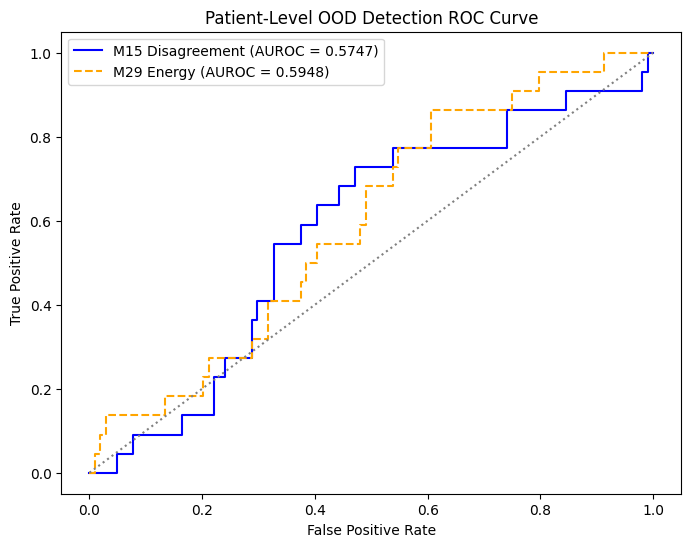

In [13]:
# ============================================================
# Section 5 & 6: Comprehensive Evaluation & Visualization
# ============================================================
print("Calibrating fixed prototypes on Stage-0 known data...")
all_embeds, all_dlbls = [], []
with torch.no_grad():
    for specs, slbl, dlbl, is_unk, pid in tqdm(known_loader):
        embeds = backbone.get_embedding(specs.to(DEVICE))
        z = proto_head.project(embeds)
        all_embeds.append(z)
        all_dlbls.append(dlbl.to(DEVICE))

z_all = torch.cat(all_embeds)
d_all = torch.cat(all_dlbls)
fixed_prototypes = proto_head.compute_prototypes(z_all, d_all)

M_IMPLIED = torch.tensor([
    [0.05, 0.90, 0.05],
    [0.60, 0.10, 0.30],
    [0.85, 0.05, 0.10],
    [0.90, 0.02, 0.08],
], dtype=torch.float32, device=DEVICE)

def score_dataset(loader):
    p_dis, p_en, p_unk = defaultdict(list), defaultdict(list), {}
    latencies = []
    with torch.no_grad():
        for specs, slbl, dlbl, is_unk, pids in tqdm(loader):
            start_t = time.time()
            specs = specs.to(DEVICE)
            s_logits = backbone(specs)
            z = proto_head.project(backbone.get_embedding(specs))
            d_logits = proto_head(z, fixed_prototypes)
            
            p_s_implied = torch.matmul(F.softmax(s_logits, dim=-1), M_IMPLIED)
            p_d = F.softmax(d_logits, dim=-1)
            
            dis = torch.norm(p_s_implied - p_d, p=2, dim=-1).cpu().numpy()
            en = -1.0 * torch.logsumexp(s_logits, dim=-1).cpu().numpy()
            latencies.append((time.time() - start_t) / len(pids))
            
            for i, p in enumerate(pids):
                pid = int(p)
                p_dis[pid].append(dis[i])
                p_en[pid].append(en[i])
                p_unk[pid] = is_unk[i].item()
    
    pids = sorted(list(p_dis.keys()))
    return np.array([p_unk[p] for p in pids]), np.array([np.mean(p_dis[p]) for p in pids]), np.array([np.mean(p_en[p]) for p in pids]), np.mean(latencies)

y_k, dis_k, en_k, lat_k = score_dataset(known_loader)
y_u, dis_u, en_u, lat_u = score_dataset(unknown_loader)
inference_time_ms = (lat_k + lat_u) / 2 * 1000

y_all = np.concatenate([y_k, y_u])
dis_all = np.concatenate([dis_k, dis_u])
en_all = np.concatenate([en_k, en_u])

fpr, tpr, _ = roc_curve(y_all, dis_all)
auroc_dis = auc(fpr, tpr)
aupr_dis = average_precision_score(y_all, dis_all)

fpr_e, tpr_e, _ = roc_curve(y_all, en_all)
auroc_e = auc(fpr_e, tpr_e)
aupr_e = average_precision_score(y_all, en_all)

print(f"\nM15 v6 (Fixed Prototypes) AUROC: {auroc_dis:.4f} | AUPR: {aupr_dis:.4f}")
print(f"M29 Baseline Energy AUROC: {auroc_e:.4f} | AUPR: {aupr_e:.4f}")

# Plots
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'M15 Disagreement (AUROC = {auroc_dis:.4f})', color='blue')
plt.plot(fpr_e, tpr_e, label=f'M29 Energy (AUROC = {auroc_e:.4f})', color='orange', linestyle='--')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Patient-Level OOD Detection ROC Curve')
plt.legend()
plt.savefig(os.path.join(CFG['results_dir'], 'ood_roc_curve.png'), dpi=150)
plt.show()


In [14]:
# ============================================================
# Section 7: Exporting Protocol-Compliant Results JSON
# ============================================================
import datetime
results = {
    "meta": {
        "model_id": "M15",
        "model_name": "Cross-Task Consistency Scorer (v6)",
        "contributor": "System",
        "date_completed": datetime.datetime.now().strftime("%Y-%m-%d"),
        "is_augmented": False,
        "augmentation_method": "none",
        "notes": "v6 explicitly fixes prototype bug by caching correct class means on Known set before inference."
    },
    "config": CFG,
    "environment": {
        "platform": "Kaggle",
        "gpu_name": GPU_NAME,
        "pytorch_version": torch.__version__
    },
    "dataset_info": {
        "dataset": "ICBHI_2017",
        "train_samples": len(dk),
        "test_samples": len(du),
        "split_method": "patient_independent"
    },
    "efficiency": {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "training_time_total_s": 0,
        "training_time_per_epoch_s_avg": 0,
        "gpu_name": GPU_NAME,
        "inference_time_ms_per_sample": round(inference_time_ms, 2)
    },
    "best_epoch": {
        "epoch": None,
        "primary_metric": "auroc",
        "primary_metric_value": round(auroc_dis, 4)
    },
    "best_metrics": {
        "accuracy": 0.0, "precision_macro": 0.0, "recall_macro": 0.0, "f1_macro": 0.0, "specificity_macro": 0.0, "icbhi_score": 0.0,
        "per_class": {}, "confusion_matrix_raw": [], "confusion_matrix_normalized": [],
        "open_set": {
            "best_score_name": "Disagreement",
            "auroc": round(auroc_dis, 4),
            "aupr": round(aupr_dis, 4),
            "baseline_energy_auroc": round(auroc_e, 4)
        }
    },
    "ablation": {
        "ablation_group": "rejection_method",
        "ablation_role": "variant",
        "baseline_model_id": "M29",
        "variable_changed": "rejection signal: cross-task disagreement (M15) instead of Energy (M29)",
        "variables_held_constant": ["backbone", "preprocessing", "data_split"],
        "component_flags": {
            "has_sound_event_head": True,
            "has_disease_head": True,
            "has_cross_task_consistency": True,
            "has_cqkd_regularization": False,
            "has_openmax_rejection": False,
            "owl_stage": 1,
            "compression_clusters": None
        },
        "loss_weights": {"sound_event_weight": 1.0, "disease_weight": 1.0, "consistency_weight": 1.0}
    },
    "training_history": []
}
rpath = os.path.join(CFG['results_dir'], 'results_M15.json')
with open(rpath, 'w') as f: json.dump(results, f, indent=2)
print(f"✅ Saved protocol-compliant JSON: {rpath}")


✅ Saved protocol-compliant JSON: /kaggle/working/results/results_M15.json


In [15]:
# ============================================================
# FINAL CELL — TEAM HANDOFF & ONE-CLICK FILE DOWNLOADS
# ============================================================
import os
import shutil
import glob
from IPython.display import display, FileLink

print("=" * 60)
print("OFFICIAL PROTOCOL OUTPUTS READY FOR DOWNLOAD")
print("=" * 60)

# 1. Grab exactly the files specified in §9 of Model_Training_Protocol.md
protocol_files = sorted(
    glob.glob(os.path.join(CFG["ckpt_dir"], "best_model.pth")) +
    glob.glob(os.path.join(CFG["results_dir"], "results_M*.json")) +
    glob.glob(os.path.join(CFG["results_dir"], "*.png"))
)

for fpath in protocol_files:
    if os.path.exists(fpath):
        size_mb = round(os.path.getsize(fpath) / (1024 * 1024), 2)
        print(f"Ready: {os.path.basename(fpath):<25} ({size_mb} MB)")
        display(FileLink(fpath))
    else:
        print(f"Missing: {os.path.basename(fpath)}")

# 2. Create a clean ZIP archive of only the official protocol files
bundle_dir = "/kaggle/working/protocol_bundle"
if protocol_files:
    os.makedirs(bundle_dir, exist_ok=True)
    for fpath in protocol_files:
        if os.path.exists(fpath):
            shutil.copy2(fpath, os.path.join(bundle_dir, os.path.basename(fpath)))
    
    zip_path = shutil.make_archive("/kaggle/working/model_handoff_bundle", 'zip', bundle_dir)
    size_zip = round(os.path.getsize(zip_path) / (1024 * 1024), 2)
    print(f"\nOr download all official files in a single ZIP bundle ({size_zip} MB):")
    display(FileLink("model_handoff_bundle.zip"))
print("=" * 60)


OFFICIAL PROTOCOL OUTPUTS READY FOR DOWNLOAD
Ready: ood_roc_curve.png         (0.06 MB)


/kaggle/working/results/ood_roc_curve.png

Ready: results_M15.json          (0.0 MB)


/kaggle/working/results/results_M15.json


Or download all official files in a single ZIP bundle (0.06 MB):


/kaggle/working/model_handoff_bundle.zip